In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

print("Libraries loaded successfully")

Libraries loaded successfully


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [5]:
# Standard data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# yfinance  — free library to download stock price history
import yfinance as yf

# VADER    — sentiment analyser built for short financial/social media text
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# scipy    — for the Pearson correlation test
from scipy import stats

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('All libraries loaded.')

All libraries loaded.


# Financial News Sentiment Analysis
## Week 1 — Exploratory Data Analysis

In [6]:
news_data = {
    "headline": [
        "Tesla stock rises after strong earnings",
        "Apple faces supply chain issues",
        "Microsoft announces new AI tools",
        "Amazon shares fall amid market concerns",
        "Google reports positive quarterly growth"
    ]
}

df = pd.DataFrame(news_data)

df

,headline
0,Tesla stock rises after strong earnings
1,Apple faces supply chain issues
2,Microsoft announces new AI tools
3,Amazon shares fall amid market concerns
4,Google reports positive quarterly growth


In [7]:
sia = SentimentIntensityAnalyzer()

df["sentiment_score"] = df["headline"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

df

,headline,sentiment_score
0,Tesla stock rises after strong earnings,0.5106
1,Apple faces supply chain issues,0.0000
2,Microsoft announces new AI tools,0.0000
3,Amazon shares fall amid market concerns,0.4404
4,Google reports positive quarterly growth,0.7351


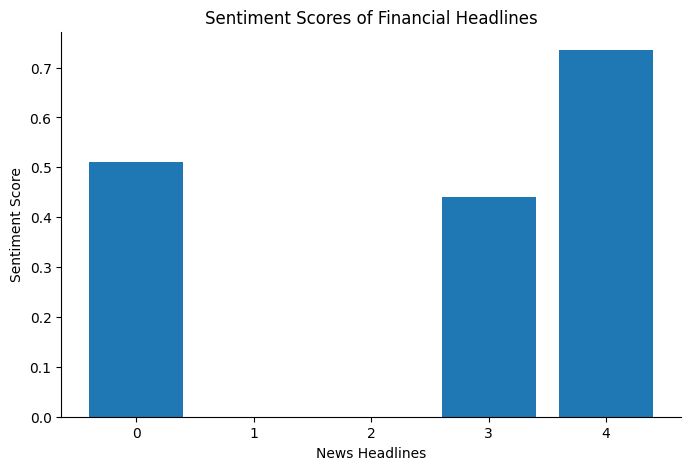

In [8]:
plt.figure(figsize=(8,5))
plt.bar(df.index, df["sentiment_score"])
plt.title("Sentiment Scores of Financial Headlines")
plt.xlabel("News Headlines")
plt.ylabel("Sentiment Score")
plt.show()

[*********************100%***********************]  1 of 1 completed


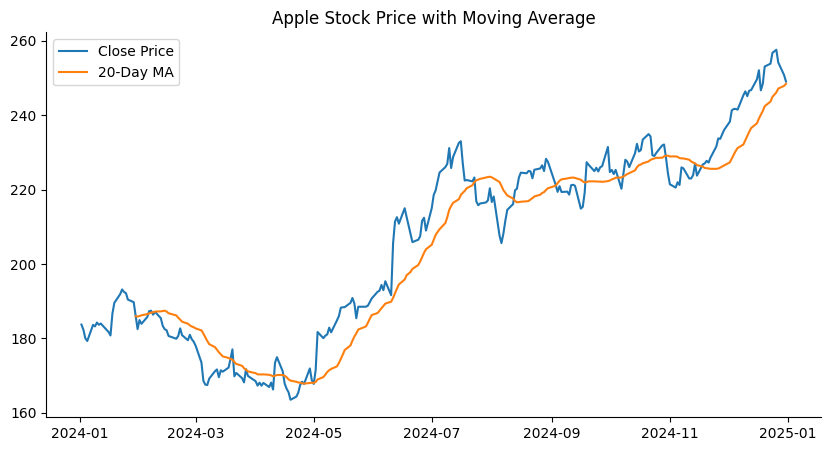

In [9]:
import yfinance as yf
#Download stock data
df=yf.download("AAPL",start="2024-01-01",end="2025-01-01")
#Create 20-day moving average
df["MA20"] = df["Close"].rolling(window=20).mean()
#Plot
plt.figure(figsize=(10,5))
plt.plot(df["Close"],label="Close Price")
plt.plot(df["MA20"],label="20-Day MA")
plt.legend()
plt.title("Apple Stock Price with Moving Average")
plt.show()

# Data Cleaning
This section handles missing values, duplicate records, and dataset structure validation before performing analysis.

In [10]:
%whos

Variable                     Type                          Data/Info
--------------------------------------------------------------------
CountVectorizer              type                          <class 'sklearn.feature_e<...>on.text.CountVectorizer'>
SentimentIntensityAnalyzer   type                          <class 'nltk.sentiment.va<...>timentIntensityAnalyzer'>
TfidfVectorizer              type                          <class 'sklearn.feature_e<...>on.text.TfidfVectorizer'>
df                           DataFrame                     Shape: (252, 6)
mticker                      module                        <module 'matplotlib.ticke<...>\\matplotlib\\ticker.py'>
news_data                    dict                          n=1
nltk                         module                        <module 'nltk' from 'c:\\<...>ages\\nltk\\__init__.py'>
np                           module                        <module 'numpy' from 'c:\<...>ges\\numpy\\__init__.py'>
pd                           modul

In [11]:
df.isnull().sum()

Price   Ticker
Close   AAPL       0
High    AAPL       0
Low     AAPL       0
Open    AAPL       0
Volume  AAPL       0
MA20              19
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df.drop_duplicates()

In [14]:
print(df.shape)

(252, 6)


In [15]:
print(df.columns)

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL'),
            (  'MA20',     '')],
           names=['Price', 'Ticker'])


In [16]:
!pip install ta

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29432 sha256=14334cfc8ce505ae9f84001b4920192e79b19ec27bf91d2b55a6ebf78215be6a
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\ec\b6\81\d781ff040ee9432384560f29596ee14ca79d70529d4228e50f
Successfully built ta



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
from ta.momentum import RSIIndicator

from ta.trend import MACD

# RSI Technical Indicator
Relative Strength Index (RSI) measures stock momentum and identifies overbought or oversold market conditions.

In [18]:
df['RSI'] = RSIIndicator(close=df['Close']['AAPL']).rsi()

print(df[['RSI']].tail())

Price             RSI
Ticker               
Date                 
2024-12-24  75.750280
2024-12-26  76.452880
2024-12-27  67.626262
2024-12-30  60.225605
2024-12-31  56.715881


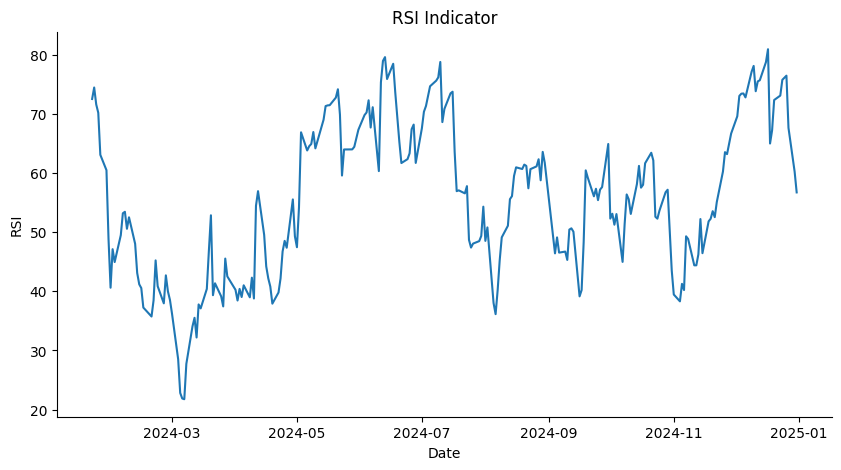

In [19]:
plt.figure(figsize=(10,5))

plt.plot(df.index, df['RSI'])

plt.title('RSI Indicator')

plt.xlabel('Date')

plt.ylabel('RSI')

plt.show()

# MACD Technical Indicator
MACD helps identify trend direction and momentum changes in stock prices.

In [20]:
macd = MACD(close=df['Close']['AAPL'])

df['MACD'] = macd.macd()

df['MACD_Signal'] = macd.macd_signal()

print(df[['MACD', 'MACD_Signal']].tail())

Price           MACD MACD_Signal
Ticker                          
Date                            
2024-12-24  6.041000    5.366787
2024-12-26  6.272683    5.547967
2024-12-27  6.110586    5.660490
2024-12-30  5.644994    5.657391
2024-12-31  5.074658    5.540845


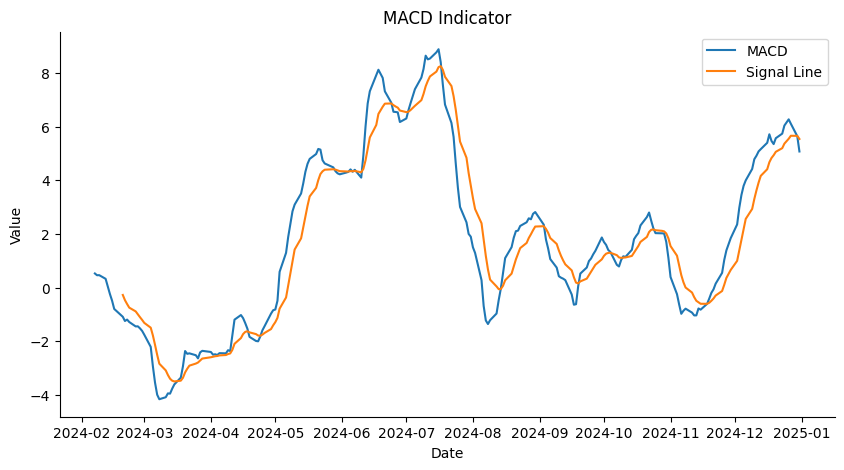

In [21]:
plt.figure(figsize=(10,5))

plt.plot(df.index, df['MACD'], label='MACD')

plt.plot(df.index, df['MACD_Signal'], label='Signal Line')

plt.title('MACD Indicator')

plt.xlabel('Date')

plt.ylabel('Value')

plt.legend()

plt.show()